# **KeduaKali - Hybrid Feature Augmentation Recommender**



Notebook ini mengimplementasikan **Hybrid Recommendation System** untuk platform KeduaKali, yang bertujuan mengurangi food waste di restoran dengan cara merekomendasikan menu-menu yang berpotensi surplus kepada pelanggan yang paling relevan.

## **1. Import Library & Konfigurasi Global**

Seluruh library, konstanta path, dan konfigurasi seed untuk reproducibility didefinisikan di sini.

In [145]:
from __future__ import annotations

import json
import os
import random
import re
import gdown
from pathlib import Path
from typing import Dict, Iterable, Optional

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Path Dataset
DATA_DIR = Path(os.getenv("DATA_DIR", "."))
SALES_PATH          = DATA_DIR / "restaurant_sales_data.csv"
WASTE_PATH          = DATA_DIR / "food_wastage_data.csv"
SURPLUS_PATH = DATA_DIR / "surplus_predictions.csv"

# Path Artefak Output
ARTIFACT_DIR        = Path("artifacts_hybrid_recommender")
LOG_DIR             = ARTIFACT_DIR / "tensorboard_logs"
NCF_MODEL_PATH      = ARTIFACT_DIR / "kedua_kali_ncf_model.keras"
HYBRID_FEATURES_PATH= ARTIFACT_DIR / "hybrid_augmented_features.npy"
HYBRID_META_PATH    = ARTIFACT_DIR / "hybrid_item_metadata.csv"
PREPROCESS_PATH     = ARTIFACT_DIR / "hybrid_preprocess_artifacts.joblib"
METRICS_PATH        = ARTIFACT_DIR / "hybrid_evaluation_metrics.json"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"Artifact dir: {ARTIFACT_DIR.resolve()}")

TensorFlow  : 2.20.0
Artifact dir: /content/artifacts_hybrid_recommender


In [147]:
def download_from_gdrive(file_id: str, output_path: Path):
    if not output_path.exists():
        print(f"Downloading {output_path.name} from Google Drive...")

        gdown.download(id=file_id, output=str(output_path), quiet=False)
        print(f"Downloaded {output_path.name} \n")
    else:
        print(f"{output_path.name} already exists. Skipping download.\n")

SALES_FILE_ID = "1LjxmnT23oh0RC1jUYVy2q0yZ-62edYQ3"
WASTE_FILE_ID = "1x5yIk2t7BqtOPnp4ddmOsDAanGIyhcgT"

download_from_gdrive(SALES_FILE_ID, SALES_PATH)
download_from_gdrive(WASTE_FILE_ID, WASTE_PATH)

if SALES_PATH.exists() and WASTE_PATH.exists():
    print(f"Ukuran {SALES_PATH.name} : {os.path.getsize(SALES_PATH) / 1024:.2f} KB")
    print(f"Ukuran {WASTE_PATH.name}  : {os.path.getsize(WASTE_PATH) / 1024:.2f} KB")

restaurant_sales_data.csv already exists. Skipping download.

food_wastage_data.csv already exists. Skipping download.

Ukuran restaurant_sales_data.csv : 1274.18 KB
Ukuran food_wastage_data.csv  : 160.74 KB


### **1.1 Definisi Kolom & Helper Functions**

Seluruh fungsi pembantu (preprocessing teks, normalisasi, segmentasi kuantil, dan pembuatan `context_id`) didefinisikan di sini agar bisa digunakan di seluruh notebook.

In [148]:
# Definisi Kolom
TEXT_COLS = [
    "restaurant_type",
    "menu_item_name",
    "meal_type",
    "key_ingredients_tags",
    "weather_condition",
]

CONTENT_CAT_COLS = [
    "restaurant_type",
    "meal_type",
    "price_segment",
    "waste_level",
]

CONTENT_NUMERIC_COLS = [
    "actual_selling_price",
    "typical_ingredient_cost",
    "observed_market_price",
    "price_margin",
    "Wastage Food Amount",
]

REQUIRED_SALES_COLS = [
    "restaurant_type",
    "menu_item_name",
    "meal_type",
    "actual_selling_price",
    "typical_ingredient_cost",
    "observed_market_price",
    "has_promotion",
    "special_event",
    "weather_condition",
    "quantity_sold",
]


# Helper Functions
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown="ignore")


def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df


def clean_text(value: object) -> str:
    text = "" if pd.isna(value) else str(value).lower()
    text = re.sub(r"[^a-z0-9\s_,-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if text else "unknown"


def split_ingredients(value: object) -> list[str]:
    text = clean_text(value)
    parts = re.split(r"[,|;/]+", text)
    return [part.strip() for part in parts if part.strip() and part.strip() != "unknown"]


def normalize_01(values: Iterable[float]) -> np.ndarray:
    values = np.asarray(list(values), dtype="float32")
    if len(values) == 0:
        return values
    min_val, max_val = np.nanmin(values), np.nanmax(values)
    if np.isclose(max_val - min_val, 0):
        return np.zeros_like(values, dtype="float32")
    return (values - min_val) / (max_val - min_val)


def l2_normalize_np(matrix: np.ndarray, axis: int = 1, epsilon: float = 1e-8) -> np.ndarray:
    matrix = np.asarray(matrix, dtype="float32")
    norm = np.linalg.norm(matrix, axis=axis, keepdims=True)
    norm = np.maximum(norm, epsilon)
    return matrix / norm


def quantile_segment(series: pd.Series, labels: list[str], fallback: str) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").fillna(series.median())
    try:
        ranked = values.rank(method="first")
        return pd.qcut(ranked, q=len(labels), labels=labels).astype(str)
    except Exception:
        return pd.Series([fallback] * len(series), index=series.index)


def make_context_id(row: pd.Series) -> str:
    fields = [
        row.get("restaurant_id", "unknown_restaurant"),
        row.get("restaurant_type", "unknown"),
        row.get("meal_type", "unknown"),
        row.get("weather_condition", "unknown"),
        row.get("price_segment", "regular"),
        f"dow_{int(row.get('day_of_week', 0))}",
        f"weekend_{int(row.get('is_weekend', 0))}",
        f"promo_{int(row.get('has_promotion', 0))}",
        f"event_{int(row.get('special_event', 0))}",
    ]
    return "|".join(clean_text(field) for field in fields)


def make_context_from_request(
    restaurant_type: str,
    meal_type: str,
    weather_condition: str,
    restaurant_id: str = "unknown_restaurant",
    price_segment: str = "regular",
    day_of_week: int = 0,
    is_weekend: int = 0,
    has_promotion: int = 0,
    special_event: int = 0,
) -> str:
    row = pd.Series({
        "restaurant_id": restaurant_id,
        "restaurant_type": restaurant_type,
        "meal_type": meal_type,
        "weather_condition": weather_condition,
        "price_segment": price_segment,
        "day_of_week": day_of_week,
        "is_weekend": is_weekend,
        "has_promotion": has_promotion,
        "special_event": special_event,
    })
    return make_context_id(row)


print("Kolom dan helper functions berhasil didefinisikan.")

Kolom dan helper functions berhasil didefinisikan.


In [149]:
def validate_surplus_csv(path: Path = SURPLUS_PATH) -> pd.DataFrame | None:

    if not path.exists():
        print("[WARNING] surplus_predictions.csv belum ditemukan.")
        print("[INFO] Inference akan memakai Wastage Food Amount sebagai fallback demo.")
        return None

    surplus_df = clean_column_names(pd.read_csv(path))

    if "menu_item_name" not in surplus_df.columns:
        raise ValueError("Kolom wajib belum ada: menu_item_name")

    if "predicted_surplus" not in surplus_df.columns:
        required = {"planned_stock", "predicted_quantity_sold"}
        if required.issubset(surplus_df.columns):
            planned_stock = pd.to_numeric(surplus_df["planned_stock"], errors="coerce").fillna(0)
            predicted_sold = pd.to_numeric(surplus_df["predicted_quantity_sold"], errors="coerce").fillna(0)
            surplus_df["predicted_surplus"] = planned_stock - predicted_sold
        else:
            raise ValueError("Harus ada predicted_surplus, atau planned_stock + predicted_quantity_sold.")

    surplus_df["predicted_surplus"] = pd.to_numeric(
        surplus_df["predicted_surplus"], errors="coerce"
    ).fillna(0).clip(lower=0)

    surplus_df["menu_key"] = surplus_df["menu_item_name"].map(clean_text)

    positive_count = surplus_df[surplus_df["predicted_surplus"] > 0]["menu_key"].nunique()
    print("[OK] surplus_predictions.csv valid.")
    print(f"Jumlah menu surplus positif: {positive_count}")

    if "planned_stock" in surplus_df.columns:
        planned_stock = pd.to_numeric(surplus_df["planned_stock"], errors="coerce")
        invalid_mask = surplus_df["predicted_surplus"] > planned_stock.fillna(np.inf)
        if invalid_mask.any():
            print("[WARNING] Ada predicted_surplus > planned_stock. Cek satuan output model Regresi.")
            display(surplus_df.loc[invalid_mask].head())

    return surplus_df

## **2. Load & Persiapan Dataset**

Fungsi `load_and_prepare_data()` menggabungkan data penjualan dengan profil rata-rata food waste per menu, lalu melakukan serangkaian preprocessing:
- Pembersihan dan normalisasi teks
- Pembuatan fitur kalender (`day_of_week`, `is_weekend`)
- Segmentasi harga (`price_segment`) dan level waste (`waste_level`)
- Perhitungan `interaction_weight` untuk training NCF
- Pembuatan `context_id` sebagai pseudo-user ID

In [150]:
def load_and_prepare_data(
    sales_path: Path = SALES_PATH,
    waste_path: Path = WASTE_PATH,
) -> pd.DataFrame:

    if not sales_path.exists():
        raise FileNotFoundError(
            f"File '{sales_path}' tidak ditemukan. Upload 'restaurant_sales_data.csv' terlebih dahulu."
        )
    if not waste_path.exists():
        raise FileNotFoundError(
            f"File '{waste_path}' tidak ditemukan. Upload 'food_wastage_data.csv' terlebih dahulu."
        )

    # Load dataset
    sales = clean_column_names(pd.read_csv(sales_path))
    waste = clean_column_names(pd.read_csv(waste_path)).drop_duplicates()

    missing_cols = [col for col in REQUIRED_SALES_COLS if col not in sales.columns]
    if missing_cols:
        raise ValueError(f"Kolom berikut tidak ada di data penjualan: {missing_cols}")

    # Gabungkan dengan profil waste rata-rata per menu
    if {"Type of Food", "Wastage Food Amount"}.issubset(waste.columns):
        waste_profile = (
            waste.groupby("Type of Food", as_index=False)["Wastage Food Amount"]
            .mean()
            .rename(columns={"Type of Food": "menu_item_name"})
        )
        df = sales.merge(waste_profile, on="menu_item_name", how="left")
    else:
        df = sales.copy()
        df["Wastage Food Amount"] = 0.0

    # Isi kolom opsional yang mungkin tidak ada
    if "key_ingredients_tags" not in df.columns:
        df["key_ingredients_tags"] = ""
    if "restaurant_id" not in df.columns:
        df["restaurant_id"] = "unknown_restaurant"

    # Fitur kalender
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["day_of_week"] = df["date"].dt.dayofweek.fillna(0).astype(int)
    else:
        df["day_of_week"] = 0
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Normalisasi teks
    for col in TEXT_COLS:
        df[col] = df[col].map(clean_text)

    # Konversi numerik
    for col in ["actual_selling_price", "typical_ingredient_cost",
                "observed_market_price", "Wastage Food Amount", "quantity_sold"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    for col in ["has_promotion", "special_event"]:
        df[col] = df[col].fillna(0).astype(int)

    # Fitur turunan
    df["price_margin"] = df["actual_selling_price"] - df["typical_ingredient_cost"]
    df["price_segment"] = quantile_segment(
        df["actual_selling_price"], ["budget", "regular", "premium"], "regular"
    )

    # Segmentasi waste level
    positive_waste = df["Wastage Food Amount"].where(df["Wastage Food Amount"] > 0)
    if positive_waste.notna().sum() >= 3:
        waste_level = quantile_segment(
            positive_waste.fillna(positive_waste.median()),
            ["low_waste", "medium_waste", "high_waste"],
            "low_waste",
        )
        df["waste_level"] = np.where(
            df["Wastage Food Amount"] <= 0, "no_waste", waste_level
        )
    else:
        df["waste_level"] = np.where(
            df["Wastage Food Amount"] <= 0, "no_waste", "high_waste"
        )

    # Key dan context ID
    df["menu_key"]   = df["menu_item_name"].map(clean_text)
    df["context_id"] = df.apply(make_context_id, axis=1)

    # Bobot interaksi untuk training NCF
    df["quantity_norm"]     = normalize_01(df["quantity_sold"])
    df["waste_norm"]        = normalize_01(df["Wastage Food Amount"])
    df["interaction_weight"] = 1.0 + 0.50 * df["quantity_norm"] + 0.50 * df["waste_norm"]

    return df.reset_index(drop=True)


# Load data
df = load_and_prepare_data()

print("─" * 50)
print(f"Shape data       : {df.shape}")
print(f"Menu unik        : {df['menu_key'].nunique()}")
print(f"Context/persona  : {df['context_id'].nunique()}")
print(f"Kolom tersedia   : {df.columns.tolist()}")
print("─" * 50)
df.head()

──────────────────────────────────────────────────
Shape data       : (10000, 24)
Menu unik        : 14
Context/persona  : 5980
Kolom tersedia   : ['date', 'restaurant_id', 'restaurant_type', 'menu_item_name', 'meal_type', 'key_ingredients_tags', 'typical_ingredient_cost', 'observed_market_price', 'actual_selling_price', 'quantity_sold', 'has_promotion', 'special_event', 'weather_condition', 'Wastage Food Amount', 'day_of_week', 'is_weekend', 'price_margin', 'price_segment', 'waste_level', 'menu_key', 'context_id', 'quantity_norm', 'waste_norm', 'interaction_weight']
──────────────────────────────────────────────────


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,...,day_of_week,is_weekend,price_margin,price_segment,waste_level,menu_key,context_id,quantity_norm,waste_norm,interaction_weight
0,2024-01-01,11,food stall,laksa,lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,...,0,0,7.98,regular,no_waste,laksa,11|food stall|lunch|sunny|regular|dow_0|weeken...,0.216427,0.0,1.108213
1,2024-01-01,7,casual dining,spaghetti carbonara,dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,...,0,0,51.46,premium,no_waste,spaghetti carbonara,7|casual dining|dinner|sunny|premium|dow_0|wee...,0.062950,0.0,1.031475
2,2024-01-01,23,fine dining,beef rendang,dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,...,0,0,71.15,premium,no_waste,beef rendang,23|fine dining|dinner|rainy|premium|dow_0|week...,0.021583,0.0,1.010791
3,2024-01-01,22,food stall,roti canai,dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,...,0,0,1.68,budget,no_waste,roti canai,22|food stall|dinner|sunny|budget|dow_0|weeken...,0.301559,0.0,1.150779
4,2024-01-01,32,fine dining,spaghetti carbonara,lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,...,0,0,46.54,premium,no_waste,spaghetti carbonara,32|fine dining|lunch|rainy|premium|dow_0|weeke...,0.157074,0.0,1.078537


## **3. Exploratory Data Analysis (EDA)**

Validasi data sebelum training: cek missing values, distribusi penjualan, dan identifikasi menu dengan food waste tertinggi.

In [151]:
# Cek Missing Values
print("Missing values per kolom:")
print(df[REQUIRED_SALES_COLS + ["Wastage Food Amount"]].isna().sum())

print("\nDistribusi quantity_sold:")
print(df["quantity_sold"].describe())

# Top 10 Menu dengan Food Waste Tertinggi
print("\nTop 10 menu dengan rata-rata food waste tertinggi:")
top_waste = (
    df.groupby("menu_item_name", as_index=False)["Wastage Food Amount"]
    .mean()
    .sort_values("Wastage Food Amount", ascending=False)
    .head(10)
)
top_waste

Missing values per kolom:
restaurant_type            0
menu_item_name             0
meal_type                  0
actual_selling_price       0
typical_ingredient_cost    0
observed_market_price      0
has_promotion              0
special_event              0
weather_condition          0
quantity_sold              0
Wastage Food Amount        0
dtype: int64

Distribusi quantity_sold:
count    10000.00000
mean       286.00040
std        217.28445
min          0.00000
25%        128.00000
50%        245.00000
75%        392.25000
max       1668.00000
Name: quantity_sold, dtype: float64

Top 10 menu dengan rata-rata food waste tertinggi:


,menu_item_name,Wastage Food Amount
0,beef rendang,0.0
1,cendol,0.0
2,char kway teow,0.0
3,chicken chop,0.0
4,chicken rice,0.0
5,iced lemon tea,0.0
6,kaya toast set,0.0
7,laksa,0.0
8,mushroom soup,0.0
9,nasi lemak,0.0


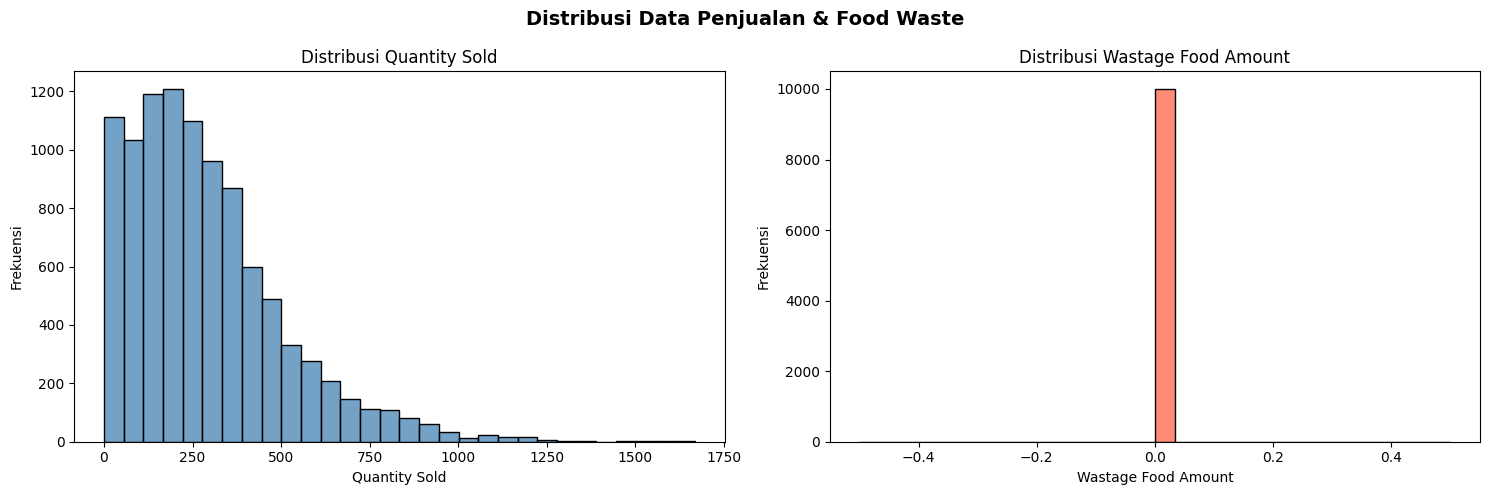

Plot disimpan ke: artifacts_hybrid_recommender/eda_quantity_waste_distribution.png


In [152]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Distribusi Data Penjualan & Food Waste", fontsize=14, fontweight="bold")

sns.histplot(df["quantity_sold"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Quantity Sold")
axes[0].set_xlabel("Quantity Sold")
axes[0].set_ylabel("Frekuensi")

sns.histplot(df["Wastage Food Amount"], bins=30, ax=axes[1], color="tomato")
axes[1].set_title("Distribusi Wastage Food Amount")
axes[1].set_xlabel("Wastage Food Amount")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "eda_quantity_waste_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot disimpan ke: {ARTIFACT_DIR / 'eda_quantity_waste_distribution.png'}")

## **4. Membangun Interaksi Context-Menu untuk NCF**

Dataset tidak memiliki `user_id` konsumen asli, sehingga kita menggunakan **`context_id` sebagai pseudo-user/persona** — kombinasi dari `restaurant_type`, `meal_type`, `weather_condition`, `price_segment`, `day_of_week`, `is_weekend`, `has_promotion`, dan `special_event`.

Model belajar memetakan pola:
- Konteks cuaca → menu yang cocok
- Meal type → preferensi menu
- Promo/event/weekend → pola pemilihan menu

**Strategi Negatif Sampling (diperbaiki):**
- `negative_ratio = 1` → rasio 1:1 lebih seimbang untuk 14 item
- Pure random sampling (tanpa hard negative) untuk menghindari noise dengan katalog kecil
- Ini mencegah overfitting pada distribusi label yang tidak seimbang


In [153]:
def build_menu_catalog(df: pd.DataFrame) -> pd.DataFrame:

    aggregations = {
        "restaurant_id": "first",
        "restaurant_type": "first",
        "menu_item_name": "first",
        "meal_type": "first",
        "key_ingredients_tags": "first",
        "weather_condition": "first",
        "actual_selling_price": "median",
        "typical_ingredient_cost": "median",
        "observed_market_price": "median",
        "Wastage Food Amount": "mean",
        "has_promotion": "max",
        "special_event": "max",
        "is_weekend": "max",
        "price_margin": "median",
        "price_segment": "first",
        "waste_level": "first",
        "quantity_sold": "mean",
        "quantity_norm": "mean",
        "waste_norm": "mean",
    }
    return df.groupby("menu_key", as_index=False).agg(aggregations).reset_index(drop=True)


def build_interaction_pairs(
    df: pd.DataFrame,
    catalog: pd.DataFrame,
    negative_ratio: int = 1,  # DIPERBAIKI: 1:1 lebih seimbang untuk 14 item
    max_positive_rows: int = 80_000,
) -> pd.DataFrame:

    rng = np.random.default_rng(SEED)

    positives = df.copy()
    if len(positives) > max_positive_rows:
        positives = positives.sample(max_positive_rows, random_state=SEED)
    positives = positives.reset_index(drop=True)

    # Target skor relevansi kontinu
    positives["target_score"] = (
    0.60
    + 0.25 * positives["quantity_norm"].astype("float32")
    + 0.15 * positives["waste_norm"].astype("float32")
    ).clip(0.60, 1.0)

    pos_pairs = pd.DataFrame({
        "context_id": positives["context_id"].values,
        "menu_key": positives["menu_key"].values,
        "label": np.ones(len(positives), dtype="float32"),
        "target_score": positives["target_score"].astype("float32").values,
        "sample_weight": positives["interaction_weight"].astype("float32").values,
    })

    # Bangun lookup untuk negative sampling
    positive_items_by_context = (
        df.groupby("context_id")["menu_key"]
        .apply(lambda vals: set(vals.astype(str)))
        .to_dict()
    )
    all_items = catalog["menu_key"].values

    # DIPERBAIKI: Pure random negative sampling (tanpa hard negative)
    # Hard negative 65% same-meal terlalu noisy untuk katalog 14 item
    negative_frames = []
    for _ in range(negative_ratio):
        sampled_items = []
        for _, row in positives.iterrows():
            positive_items = positive_items_by_context.get(row["context_id"], set())
            # Pure random dari seluruh katalog
            clean_pool = [item for item in all_items if item not in positive_items]
            if not clean_pool:
                clean_pool = [item for item in all_items if item != row["menu_key"]]
            sampled_items.append(rng.choice(clean_pool))

        negative_frames.append(pd.DataFrame({
            "context_id": positives["context_id"].values,
            "menu_key": np.asarray(sampled_items),
            "label": np.zeros(len(positives), dtype="float32"),
            "target_score": np.zeros(len(positives), dtype="float32"),
            "sample_weight": np.ones(len(positives), dtype="float32"),
        }))

    pairs = pd.concat([pos_pairs, *negative_frames], ignore_index=True)
    pairs = pairs.drop_duplicates(subset=["context_id", "menu_key", "label"], keep="first")
    pairs = pairs.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return pairs


# Bangun katalog dan pasangan interaksi
menu_catalog = build_menu_catalog(df)
pair_df = build_interaction_pairs(df, menu_catalog, negative_ratio=1)  # DIPERBAIKI: 1:1

# Encode context dan menu ke indeks integer
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
pair_df["user_idx"] = user_encoder.fit_transform(pair_df["context_id"])
item_encoder.fit(menu_catalog["menu_key"])
pair_df["item_idx"] = item_encoder.transform(pair_df["menu_key"])

num_users = pair_df["user_idx"].nunique()
num_items = len(item_encoder.classes_)

# Split 70% train / 15% val / 15% test (stratified by label)
train_pairs, temp_pairs = train_test_split(
    pair_df, test_size=0.30, random_state=SEED, stratify=pair_df["label"]
)
val_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.50, random_state=SEED, stratify=temp_pairs["label"]
)

print("─" * 50)
print(f"Total pairs      : {pair_df.shape}")
print(f"Train / Val / Test: {train_pairs.shape} / {val_pairs.shape} / {test_pairs.shape}")
print(f"Num users/context: {num_users}")
print(f"Num items/menu   : {num_items}")
print("\nProporsi label:")
print(pair_df["label"].value_counts(normalize=True))
print("─" * 50)


──────────────────────────────────────────────────
Total pairs      : (16678, 7)
Train / Val / Test: (11674, 7) / (2502, 7) / (2502, 7)
Num users/context: 5980
Num items/menu   : 14

Proporsi label:
label
0.0    0.565775
1.0    0.434225
Name: proportion, dtype: float64
──────────────────────────────────────────────────


## **5. Pipeline tf.data untuk Training — Context-Aware Ranker**

Dataset dikonversi ke format `tf.data.Dataset`. Berbeda dari sebelumnya yang hanya memakai ID embedding, sekarang kita langsung menggunakan **dense feature vector** dari konteks dan item sebagai input — ini lebih efektif untuk katalog kecil 14 item.

- **Batch size:** 256
- **Shuffle:** aktif untuk training
- **Prefetch:** `tf.data.AUTOTUNE`


In [154]:
BATCH_SIZE = 256  # DIPERBAIKI: lebih kecil agar gradien lebih stabil

# Encoder konteks — difit dulu sebelum dataset dibuat
CONTEXT_CAT_COLS = ["restaurant_type", "meal_type", "weather_condition", "price_segment"]
CONTEXT_NUM_COLS = ["day_of_week", "is_weekend", "has_promotion", "special_event"]

context_ohe = make_one_hot_encoder()
# Fit pada df asli agar semua kategori ter-cover
context_ohe.fit(df[CONTEXT_CAT_COLS].fillna("unknown"))


def build_context_feature_matrix(frame: pd.DataFrame) -> np.ndarray:
    """Konversi baris pair_df jadi dense context feature vector."""
    merged = frame.merge(
        df[["context_id"] + CONTEXT_CAT_COLS + CONTEXT_NUM_COLS].drop_duplicates("context_id"),
        on="context_id",
        how="left",
    )
    x_cat = context_ohe.transform(
        merged[CONTEXT_CAT_COLS].fillna("unknown")
    ).astype("float32")
    x_num = merged[CONTEXT_NUM_COLS].fillna(0).astype("float32").values
    return np.hstack([x_cat, x_num])


def frame_to_context_dataset(
    frame: pd.DataFrame,
    item_content_features: np.ndarray,
    batch_size: int = BATCH_SIZE,
    shuffle: bool = False,
) -> tf.data.Dataset:
    """Buat tf.data.Dataset dengan context features + item content features."""

    context_feats = build_context_feature_matrix(frame)  # (N, context_dim)
    item_rows     = frame["item_idx"].values
    item_feats    = item_content_features[item_rows]      # (N, item_dim)

    inputs  = {
        "context_input": context_feats,
        "item_input":    item_feats,
    }
    labels  = frame[["target_score", "label"]].astype("float32").values
    weights = frame["sample_weight"].astype("float32").values.reshape(-1, 1)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, labels, weights))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(frame), 200_000), seed=SEED)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# Dataset akan dibuat setelah content_features tersedia
# Simpan dulu context_dim untuk arsitektur model
_sample_ctx = build_context_feature_matrix(pair_df.head(1))
context_dim = _sample_ctx.shape[1]
print(f"Context feature dimension: {context_dim}")
print("Dataset builder siap. Dataset akan dibuat setelah content_features tersedia.")


Context feature dimension: 18
Dataset builder siap. Dataset akan dibuat setelah content_features tersedia.


## **6. Arsitektur Deep Learning: Context-Aware Neural Ranker**

Arsitektur diganti dari NeuMF berbasis ID-embedding menjadi **Context-Aware Neural Ranker** yang bekerja pada dense feature vectors. Ini lebih efektif untuk katalog kecil (14 item) karena:

| Aspek | NeuMF Lama | Context-Aware Ranker Baru |
|---|---|---|
| Input | ID integer (sparse) | Dense feature vector |
| Generalisasi | Hafal context ID | Pelajari pola fitur |
| Overfitting risk | Sangat tinggi (5980 user emb) | Terkontrol |
| Cold start | Tidak bisa | Bisa langsung |

Komponen Custom yang digunakan:

* L2Normalize (Custom Layer)
* DemandWeightedBCELoss (Custom Loss) dengan mae_weight = 0.80
* ManualTrainingLogger (Custom Callback)

In [155]:
# Custom Layer: L2Normalize
@tf.keras.utils.register_keras_serializable(package="KeduaKali")
class L2Normalize(tf.keras.layers.Layer):

    def __init__(self, axis: int = -1, epsilon: float = 1e-8, **kwargs):
        super().__init__(**kwargs)
        self.axis    = axis
        self.epsilon = epsilon

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.math.l2_normalize(inputs, axis=self.axis, epsilon=self.epsilon)

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({"axis": self.axis, "epsilon": self.epsilon})
        return config


# Custom Loss: DemandWeightedBCELoss
@tf.keras.utils.register_keras_serializable(package="KeduaKali")
class DemandWeightedBCELoss(tf.keras.losses.Loss):

    def __init__(
        self,
        mae_weight: float = 0.10,
        reduction=tf.keras.losses.Reduction.NONE,
        **kwargs,
    ):
        super().__init__(reduction=reduction, **kwargs)
        self.mae_weight = mae_weight

    def call(self, y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
        bce    = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        bce    = tf.reshape(bce, tf.shape(y_true))
        mae    = tf.abs(y_true - y_pred)
        return bce + self.mae_weight * mae

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({"mae_weight": self.mae_weight})
        return config


# Custom Callback: ManualTrainingLogger
class ManualTrainingLogger(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch: int, logs: Optional[dict] = None):
        logs       = logs or {}
        metric_txt = " │ ".join(f"{k}: {v:.4f}" for k, v in logs.items())
        print(f"Epoch {epoch + 1:02d} │ {metric_txt}")


print("Custom components berhasil didefinisikan:")
print("   - L2Normalize (Custom Layer)")
print("   - DemandWeightedBCELoss (Custom Loss)")
print("   - ManualTrainingLogger (Custom Callback)")

Custom components berhasil didefinisikan:
   - L2Normalize (Custom Layer)
   - DemandWeightedBCELoss (Custom Loss)
   - ManualTrainingLogger (Custom Callback)


In [156]:
# ============================================================
# Context-Aware Neural Ranker
# ============================================================

def build_context_aware_ranker(
    context_dim: int,
    item_dim: int,
) -> tf.keras.Model:

    l2_reg = tf.keras.regularizers.l2(1e-3)

    # === Context Tower ===
    context_input = tf.keras.Input(shape=(context_dim,), name="context_input")
    cx = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=l2_reg, name="ctx_dense_1")(context_input)
    cx = tf.keras.layers.BatchNormalization(name="ctx_bn_1")(cx)
    cx = tf.keras.layers.Dropout(0.3, name="ctx_drop_1")(cx)
    cx = tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=l2_reg, name="ctx_dense_2")(cx)
    cx = tf.keras.layers.BatchNormalization(name="ctx_bn_2")(cx)

    # === Item Tower ===
    item_input = tf.keras.Input(shape=(item_dim,), name="item_input")
    it = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=l2_reg, name="item_dense_1")(item_input)
    it = tf.keras.layers.BatchNormalization(name="item_bn_1")(it)
    it = tf.keras.layers.Dropout(0.3, name="item_drop_1")(it)
    it = tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=l2_reg, name="item_dense_2")(it)
    it = tf.keras.layers.BatchNormalization(name="item_bn_2")(it)

    # === Interaction Layer ===
    dot = tf.keras.layers.Dot(axes=1, normalize=True, name="context_item_dot")([cx, it])
    merged = tf.keras.layers.Concatenate(name="fusion")([cx, it, dot])

    # === Prediction Head ===
    x = tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=l2_reg, name="head_dense_1")(merged)
    x = tf.keras.layers.Dropout(0.2, name="head_drop")(x)
    x = tf.keras.layers.Dense(8, activation="relu", kernel_regularizer=l2_reg, name="head_dense_2")(x)
    output = tf.keras.layers.Dense(1, activation="sigmoid", name="relevance_score")(x)

    return tf.keras.Model(
        inputs={"context_input": context_input, "item_input": item_input},
        outputs=output,
        name="context_aware_ranker",
    )

print(f"Context dim siap: {context_dim}")
print("Model akan diinisialisasi setelah content_features tersedia (Section 9).")

Context dim siap: 18
Model akan diinisialisasi setelah content_features tersedia (Section 9).


## **7. Content-Based Features dari Metadata Menu**

Tiga jenis fitur konten diekstrak dari katalog menu dan kemudian digabungkan:

| Fitur | Encoder | Dimensi |
|---|---|---|
| Ingredients (teks) | `MultiLabelBinarizer` | Jumlah bahan unik |
| Kategori (restaurant_type, meal_type, dll.) | `OneHotEncoder` | Jumlah kategori unik |
| Numerik (harga, margin, waste) | `StandardScaler` | 5 |

Seluruh fitur digabung dan dinormalisasi L2 menjadi **content feature matrix**.


In [157]:
def build_content_features(catalog: pd.DataFrame):

    catalog = catalog.copy().reset_index(drop=True)

    # Fitur 1: Ingredients (MultiLabelBinarizer)
    ingredient_lists    = catalog["key_ingredients_tags"].map(split_ingredients)
    ingredient_encoder  = MultiLabelBinarizer()
    x_ingredients       = ingredient_encoder.fit_transform(ingredient_lists).astype("float32")

    # Fitur 2: Kategori (OneHotEncoder)
    category_encoder = make_one_hot_encoder()
    x_category       = category_encoder.fit_transform(catalog[CONTENT_CAT_COLS]).astype("float32")

    # Fitur 3: Numerik (StandardScaler)
    numeric_scaler = StandardScaler()
    numeric_frame  = catalog[CONTENT_NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    x_numeric      = numeric_scaler.fit_transform(numeric_frame).astype("float32")

    # Gabungkan dan normalisasi L2
    content_features = np.hstack([x_ingredients, x_category, x_numeric]).astype("float32")
    content_features = l2_normalize_np(content_features)

    return content_features, ingredient_encoder, category_encoder, numeric_scaler


content_features, ingredient_encoder, category_encoder, content_numeric_scaler = \
    build_content_features(menu_catalog)

print(f"Content feature shape: {content_features.shape}")
print(f"  - Ingredients dim : {ingredient_encoder.classes_.shape[0]}")
print(f"  - Category dim    : {category_encoder.transform(menu_catalog[CONTENT_CAT_COLS]).shape[1]}")
print(f"  - Numeric dim     : {len(CONTENT_NUMERIC_COLS)}")

Content feature shape: (14, 74)
  - Ingredients dim : 58
  - Category dim    : 11
  - Numeric dim     : 5


## **8. Inisialisasi Model + Custom Training Loop**

Model diinisialisasi setelah `content_features`. Training menggunakan:
- Maximum Epochs: 100
- Early Stopping: patience = 10 berdasarkan validasi MAE
- Learning Rate Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Batch size: 256

Training dapat berhenti sebelum mencapai 100 epoch apabila tidak terjadi peningkatan pada validation MAE.

In [158]:
# ============================================================
# Inisialisasi Model setelah content_features tersedia
# ============================================================

# Ambil item_dim dari content_features (sudah dibuat di Section 9)
item_dim = content_features.shape[1]

# Build model
ncf_model = build_context_aware_ranker(context_dim, item_dim)
loss_fn   = DemandWeightedBCELoss(mae_weight=0.80, name="demand_weighted_bce")
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

ncf_model.summary()

# Buat dataset dengan context + item content features
train_ds = frame_to_context_dataset(train_pairs, content_features, shuffle=True)
val_ds   = frame_to_context_dataset(val_pairs,   content_features, shuffle=False)
test_ds  = frame_to_context_dataset(test_pairs,  content_features, shuffle=False)

# Verifikasi shape
for sample_inputs, sample_labels, sample_weights in train_ds.take(1):
    print(f"context_input shape : {sample_inputs['context_input'].shape}")
    print(f"item_input shape    : {sample_inputs['item_input'].shape}")
    print(f"labels shape        : {sample_labels.shape}")
    print(f"weights shape       : {sample_weights.shape}")


# ============================================================
# Step Functions
# ============================================================
@tf.function
def train_step(inputs: Dict[str, tf.Tensor], targets: tf.Tensor, sample_weight: tf.Tensor):
    target_score = targets[:, :1]
    with tf.GradientTape() as tape:
        predictions = ncf_model(inputs, training=True)
        loss_values = loss_fn(target_score, predictions)
        loss        = tf.reduce_mean(loss_values * sample_weight)
        # Tambahkan regularization losses dari BatchNorm dll
        loss       += tf.reduce_sum(ncf_model.losses)
    gradients = tape.gradient(loss, ncf_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, ncf_model.trainable_variables))
    return loss, predictions


@tf.function
def eval_step(inputs: Dict[str, tf.Tensor], targets: tf.Tensor, sample_weight: tf.Tensor):
    target_score = targets[:, :1]
    predictions  = ncf_model(inputs, training=False)
    loss_values  = loss_fn(target_score, predictions)
    loss         = tf.reduce_mean(loss_values * sample_weight)
    return loss, predictions


def run_epoch(dataset: tf.data.Dataset, training: bool) -> dict:
    loss_metric = tf.keras.metrics.Mean()
    acc_metric  = tf.keras.metrics.BinaryAccuracy(threshold=0.5)
    mae_metric  = tf.keras.metrics.MeanAbsoluteError()

    for inputs, targets, sample_weight in dataset:
        target_score = targets[:, :1]
        binary_label = targets[:, 1:]
        if training:
            loss, predictions = train_step(inputs, targets, sample_weight)
        else:
            loss, predictions = eval_step(inputs, targets, sample_weight)
        loss_metric.update_state(loss)
        acc_metric.update_state(binary_label, predictions)
        mae_metric.update_state(target_score, predictions)

    prefix = "train" if training else "val"
    return {
        f"{prefix}_loss"    : float(loss_metric.result().numpy()),
        f"{prefix}_accuracy": float(acc_metric.result().numpy()),
        f"{prefix}_mae"     : float(mae_metric.result().numpy()),
    }


def write_tensorboard_logs(writer: tf.summary.SummaryWriter, logs: dict, epoch: int):
    with writer.as_default():
        for key, value in logs.items():
            tf.summary.scalar(key, value, step=epoch)


# ============================================================
# Training Loop
# ============================================================
EPOCHS   = 100
PATIENCE = 10

# Learning rate scheduler
lr_patience = 5
lr_factor   = 0.5
min_lr      = 1e-5
no_improve_lr = 0

best_val_mae = np.inf
wait         = 0
history      = []

logger = ManualTrainingLogger()
logger.set_model(ncf_model)
logger.on_train_begin()

train_writer = tf.summary.create_file_writer(str(LOG_DIR / "train"))
val_writer   = tf.summary.create_file_writer(str(LOG_DIR / "val"))

print(f"Mulai training | Epochs: {EPOCHS} | Patience: {PATIENCE} | LR: {optimizer.learning_rate.numpy():.4f}")
print("─" * 80)

for epoch in range(EPOCHS):
    train_logs = run_epoch(train_ds, training=True)
    val_logs   = run_epoch(val_ds,   training=False)
    logs       = {**train_logs, **val_logs}
    history.append(logs)

    write_tensorboard_logs(train_writer, train_logs, epoch)
    write_tensorboard_logs(val_writer,   val_logs,   epoch)
    logger.on_epoch_end(epoch, logs)

    # Simpan model terbaik & early stopping
    if logs["val_mae"] < best_val_mae:
        best_val_mae  = logs["val_mae"]
        wait          = 0
        no_improve_lr = 0
        ncf_model.save(NCF_MODEL_PATH)
    else:
        wait          += 1
        no_improve_lr += 1
        # ReduceLROnPlateau manual
        if no_improve_lr >= lr_patience:
            current_lr = float(optimizer.learning_rate.numpy())
            new_lr     = max(current_lr * lr_factor, min_lr)
            optimizer.learning_rate.assign(new_lr)
            no_improve_lr = 0
            print(f"   ↓ LR diturunkan: {current_lr:.6f} → {new_lr:.6f}")
        if wait >= PATIENCE:
            print(f"\n⏹️  Early stopping pada epoch {epoch + 1}. Best val_mae: {best_val_mae:.4f}")
            break

logger.on_train_end()

# Load model terbaik
ncf_model = tf.keras.models.load_model(
    NCF_MODEL_PATH,
    custom_objects={"L2Normalize": L2Normalize, "DemandWeightedBCELoss": DemandWeightedBCELoss},
)
print(f"\nBest model dimuat dari: {NCF_MODEL_PATH}")

Model: "context_aware_ranker"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ context_input       │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 74)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctx_dense_1 (Dense) │ (None, 32)        │        608 │ context_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_dense_1        │ (None, 32)        │      2,400 │ item_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctx_bn_1            │ (None, 32)        │        128 │ ctx_dense_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bn_1           │ (None, 32)        │        128 │ item_dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctx_drop_1          │ (None, 32)        │          0 │ ctx_bn_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_drop_1         │ (None, 32)        │          0 │ item_bn_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctx_dense_2 (Dense) │ (None, 16)        │        528 │ ctx_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_dense_2        │ (None, 16)        │        528 │ item_drop_1[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctx_bn_2            │ (None, 16)        │         64 │ ctx_dense_2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bn_2           │ (None, 16)        │         64 │ item_dense_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_item_dot    │ (None, 1)         │          0 │ ctx_bn_2[0][0],   │
│ (Dot)               │                   │            │ item_bn_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 33)        │          0 │ ctx_bn_2[0][0],   │
│ (Concatenate)       │                   │            │ item_bn_2[0][0],  │
│                     │                   │            │ context_item_dot… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 16)        │        544 │ fusion[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 16)        │          0 │ head_dense_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 8)         │        136 │ head_drop[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,137 (20.07 KB)

 Trainable params: 4,945 (19.32 KB)

 Non-trainable params: 192 (768.00 B)

context_input shape : (256, 18)
item_input shape    : (256, 74)
labels shape        : (256, 2)
weights shape       : (256, 1)
Mulai training | Epochs: 100 | Patience: 10 | LR: 0.0010
────────────────────────────────────────────────────────────────────────────────
Epoch 01 │ train_loss: 1.0340 │ train_accuracy: 0.5636 │ train_mae: 0.3115 │ val_loss: 0.9474 │ val_accuracy: 0.5655 │ val_mae: 0.3351
Epoch 02 │ train_loss: 0.9841 │ train_accuracy: 0.5656 │ train_mae: 0.2956 │ val_loss: 0.9303 │ val_accuracy: 0.5655 │ val_mae: 0.3301
Epoch 03 │ train_loss: 0.9579 │ train_accuracy: 0.5658 │ train_mae: 0.2882 │ val_loss: 0.9062 │ val_accuracy: 0.5655 │ val_mae: 0.3220
Epoch 04 │ train_loss: 0.9244 │ train_accuracy: 0.5658 │ train_mae: 0.2758 │ val_loss: 0.8830 │ val_accuracy: 0.5655 │ val_mae: 0.3123
Epoch 05 │ train_loss: 0.8856 │ train_accuracy: 0.5658 │ train_mae: 0.2606 │ val_loss: 0.8364 │ val_accuracy: 0.5655 │ val_mae: 0.2919
Epoch 06 │ train_loss: 0.8278 │ train_accuracy: 0.5716 │ trai

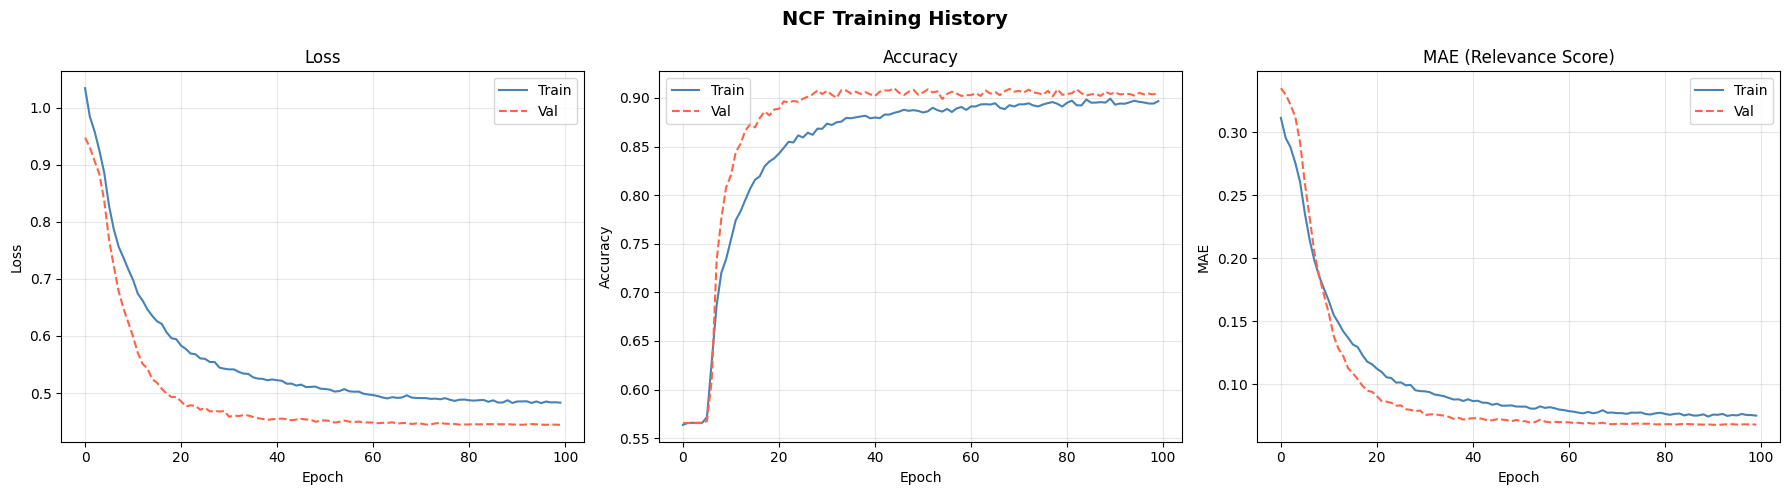

Plot disimpan ke: artifacts_hybrid_recommender/ncf_training_history.png


In [159]:
# Visualisasi Training History
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NCF Training History", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(history_df["train_loss"], label="Train", color="steelblue")
axes[0].plot(history_df["val_loss"],   label="Val",   color="tomato", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_df["train_accuracy"], label="Train", color="steelblue")
axes[1].plot(history_df["val_accuracy"],   label="Val",   color="tomato", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

# MAE
axes[2].plot(history_df["train_mae"], label="Train", color="steelblue")
axes[2].plot(history_df["val_mae"],   label="Val",   color="tomato", linestyle="--")
axes[2].set_title("MAE (Relevance Score)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "ncf_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot disimpan ke: {ARTIFACT_DIR / 'ncf_training_history.png'}")

## **9. Evaluasi Model NCF**

In [160]:
def collect_predictions(
    dataset: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    y_score_batches, y_binary_batches, y_pred_batches = [], [], []
    for inputs, targets, _ in dataset:
        predictions = ncf_model(inputs, training=False)
        y_score_batches.append(targets[:, :1].numpy())
        y_binary_batches.append(targets[:, 1:].numpy())
        y_pred_batches.append(predictions.numpy())
    return (
        np.vstack(y_score_batches).reshape(-1),
        np.vstack(y_binary_batches).reshape(-1),
        np.vstack(y_pred_batches).reshape(-1),
    )


def evaluate_ranking_at_k(test_frame: pd.DataFrame, k: int = 5) -> dict:

    positive_test = test_frame[test_frame["label"] == 1].copy()
    if positive_test.empty:
        return {f"precision_at_{k}": 0.0, f"recall_at_{k}": 0.0,
                f"hit_rate_at_{k}": 0.0, f"ndcg_at_{k}": 0.0, "coverage": 0.0}

    recommended_items = set()
    precision_scores, recall_scores, hit_scores, ndcg_scores = [], [], [], []

    all_item_keys = item_encoder.classes_
    all_item_idx  = np.arange(num_items, dtype="int32")

    for context_id, group in positive_test.groupby("context_id"):
        relevant_items = set(group["menu_key"].astype(str).values)

        # Buat context features untuk context ini
        ctx_row = pd.DataFrame([{"context_id": context_id}])
        ctx_feat = build_context_feature_matrix(ctx_row)  # (1, context_dim)
        ctx_feat_tiled = np.tile(ctx_feat, (num_items, 1))  # (num_items, context_dim)

        item_feats = content_features[all_item_idx]  # (num_items, item_dim)

        inputs = {
            "context_input": ctx_feat_tiled,
            "item_input":    item_feats,
        }
        scores      = ncf_model.predict(inputs, batch_size=256, verbose=0).reshape(-1)
        top_indices = np.argsort(scores)[::-1][:k]
        top_items   = list(all_item_keys[top_indices])
        recommended_items.update(top_items)

        hits_by_rank = [1 if item in relevant_items else 0 for item in top_items]
        hits         = sum(hits_by_rank)
        precision_scores.append(hits / k)
        recall_scores.append(hits / max(len(relevant_items), 1))
        hit_scores.append(1.0 if hits > 0 else 0.0)

        dcg  = sum(hit / np.log2(rank + 2) for rank, hit in enumerate(hits_by_rank))
        idcg = sum(1   / np.log2(rank + 2) for rank in range(min(len(relevant_items), k)))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        f"precision_at_{k}": float(np.mean(precision_scores)) if precision_scores else 0.0,
        f"recall_at_{k}"   : float(np.mean(recall_scores))    if recall_scores    else 0.0,
        f"hit_rate_at_{k}" : float(np.mean(hit_scores))       if hit_scores       else 0.0,
        f"ndcg_at_{k}"     : float(np.mean(ndcg_scores))      if ndcg_scores      else 0.0,
        "coverage"         : float(len(recommended_items) / max(num_items, 1)),
    }

def mean_reciprocal_rank(test_frame: pd.DataFrame, k: int = 5) -> float:
    positive_test = test_frame[test_frame["label"] == 1].copy()
    if positive_test.empty:
        return 0.0

    all_item_keys = item_encoder.classes_
    all_item_idx  = np.arange(num_items, dtype="int32")
    rr_scores = []

    for context_id, group in positive_test.groupby("context_id"):
        relevant_items = set(group["menu_key"].astype(str).values)

        ctx_row  = pd.DataFrame([{"context_id": context_id}])
        ctx_feat = build_context_feature_matrix(ctx_row)
        ctx_feat_tiled = np.tile(ctx_feat, (num_items, 1))

        inputs = {
            "context_input": ctx_feat_tiled,
            "item_input":    content_features[all_item_idx],
        }
        scores     = ncf_model.predict(inputs, batch_size=256, verbose=0).reshape(-1)
        top_items  = list(all_item_keys[np.argsort(scores)[::-1][:k]])

        rr = 0.0
        for rank, item in enumerate(top_items, 1):
            if item in relevant_items:
                rr = 1.0 / rank
                break
        rr_scores.append(rr)

    return float(np.mean(rr_scores)) if rr_scores else 0.0


# Jalankan evaluasi
y_true_score, y_true_binary, y_pred = collect_predictions(test_ds)
y_label = (y_pred >= 0.5).astype(int)

test_accuracy               = accuracy_score(y_true_binary.astype(int), y_label)
test_relevance_mae          = mean_absolute_error(y_true_score, y_pred)

ranking_metrics_3 = evaluate_ranking_at_k(test_pairs, k=min(3, num_items))
ranking_metrics_5 = evaluate_ranking_at_k(test_pairs, k=min(5, num_items))

metrics = {
    "task": "context_menu_binary_relevance",
    "test_accuracy": float(test_accuracy),
    "test_relevance_mae": float(test_relevance_mae),
    "accuracy_target_85pct_passed": bool(test_accuracy >= 0.85),
    "mae_target_0_02_passed": bool(test_relevance_mae <= 0.02),
    "evaluation_note": "Target MAE <= 0.02 masih menjadi area tuning. Fokus utama adalah Accuracy, HitRate, dan NDCG.",
    **ranking_metrics_3,
    "mrr_at_5": mean_reciprocal_rank(test_pairs, k=5),
    **ranking_metrics_5
}

with METRICS_PATH.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("=" * 50)
print("[INFO] Hasil Evaluasi (Test Set):")
print(json.dumps(metrics, indent=2))
print("=" * 50)
print(f"Metrik disimpan ke: {METRICS_PATH}")

[INFO] Hasil Evaluasi (Test Set):
{
  "task": "context_menu_binary_relevance",
  "test_accuracy": 0.9040767386091128,
  "test_relevance_mae": 0.06868620216846466,
  "accuracy_target_85pct_passed": true,
  "mae_target_0_02_passed": false,
  "evaluation_note": "Target MAE <= 0.02 masih menjadi area tuning. Fokus utama adalah Accuracy, HitRate, dan NDCG.",
  "precision_at_3": 0.30589719331441184,
  "recall_at_3": 0.8956165247555976,
  "hit_rate_at_3": 0.8997161778618732,
  "ndcg_at_3": 0.7240597772889799,
  "coverage": 1.0,
  "mrr_at_5": 0.6884894355093031,
  "precision_at_5": 0.20378429517502364,
  "recall_at_5": 0.9914853358561968,
  "hit_rate_at_5": 0.9914853358561968,
  "ndcg_at_5": 0.7646689406240917
}
Metrik disimpan ke: artifacts_hybrid_recommender/hybrid_evaluation_metrics.json


Hasil evaluasi menunjukkan bahwa model berhasil melampaui target accuracy sebesar 85% dengan memperoleh accuracy 90.41%.

Nilai MAE yang diperoleh adalah 0.0687 sehingga target MAE ≤ 0.02 belum tercapai dan masih memerlukan tuning lebih lanjut.

Pada metrik ranking, model menunjukkan performa yang baik dengan:
- Hit Rate@5 = 0.991
- Recall@5 = 0.991
- NDCG@5 = 0.765
- MRR@5 = 0.688

Hal ini menunjukkan bahwa sebagian besar menu relevan berhasil muncul pada rekomendasi teratas.

Coverage sebesar 1.0 menunjukkan bahwa seluruh menu dalam katalog (14 dari 14 menu) pernah direkomendasikan setidaknya satu kali selama proses evaluasi.

## **10. Hybrid Feature Matrix untuk Inference**

Untuk inference recommend_surplus_menus(), dibangun Hybrid Feature Matrix yang menggabungkan:

- Content Features (74 dimensi)
  - Ingredients Features
  - Category Features
  - Numerical Features

- Neural Item Representation dari Item Tower (16 dimensi)

Total dimensi Hybrid Feature Matrix = 90 dimensi.


In [161]:
def build_item_repr_model(ranker_model: tf.keras.Model) -> tf.keras.Model:
    item_input  = ranker_model.input["item_input"]
    # Ambil output dari layer item_bn_2 (output Item Tower)
    item_repr   = ranker_model.get_layer("item_bn_2").output
    item_repr   = L2Normalize(name="item_repr_l2")(item_repr)
    return tf.keras.Model(item_input, item_repr, name="item_repr_extractor")


def build_context_repr_model(ranker_model: tf.keras.Model) -> tf.keras.Model:
    ctx_input  = ranker_model.input["context_input"]
    ctx_repr   = ranker_model.get_layer("ctx_bn_2").output
    ctx_repr   = L2Normalize(name="ctx_repr_l2")(ctx_repr)
    return tf.keras.Model(ctx_input, ctx_repr, name="ctx_repr_extractor")


# Bangun extractor
item_repr_model = build_item_repr_model(ncf_model)
ctx_repr_model  = build_context_repr_model(ncf_model)

# Ekstrak item representations
item_embeddings = item_repr_model.predict(content_features, batch_size=256, verbose=0)
item_embeddings = l2_normalize_np(item_embeddings)

print(f"Item representation shape : {item_embeddings.shape}")
print(f"Content feature shape     : {content_features.shape}")


Item representation shape : (14, 16)
Content feature shape     : (14, 74)


In [162]:
# Bangun Hybrid Feature Matrix
# Gabungkan content_features (74 dim) + item_embeddings dari Item Tower (16 dim)
common_mask       = menu_catalog["menu_key"].isin(item_encoder.classes_)
hybrid_meta       = menu_catalog.loc[common_mask].reset_index(drop=True)
catalog_positions = menu_catalog.index[common_mask].to_numpy()
cf_indices        = item_encoder.transform(hybrid_meta["menu_key"])

content_f = content_features[catalog_positions]
emb_f     = item_embeddings[cf_indices]

hybrid_features = np.hstack([content_f, emb_f]).astype("float32")
hybrid_features = l2_normalize_np(hybrid_features)

hybrid_meta["feature_row"] = np.arange(len(hybrid_meta))
hybrid_meta.to_csv(HYBRID_META_PATH, index=False)
np.save(HYBRID_FEATURES_PATH, hybrid_features)

print(f"Hybrid feature shape : {hybrid_features.shape}")
print(f"  - Content dim      : {content_f.shape[1]}")
print(f"  - Item repr dim    : {emb_f.shape[1]}")
print(f"Hybrid features disimpan ke: {HYBRID_FEATURES_PATH}")
print(f"Hybrid metadata disimpan ke: {HYBRID_META_PATH}")


Hybrid feature shape : (14, 90)
  - Content dim      : 74
  - Item repr dim    : 16
Hybrid features disimpan ke: artifacts_hybrid_recommender/hybrid_augmented_features.npy
Hybrid metadata disimpan ke: artifacts_hybrid_recommender/hybrid_item_metadata.csv


## **11. Inference: Fungsi Rekomendasi Menu Surplus**

Fungsi `recommend_surplus_menus()` menggunakan **Context-Aware Neural Ranker** untuk scoring

In [163]:
def build_query_content_vector(
    restaurant_type: str,
    meal_type: str,
    price_segment: str = "regular",
    waste_level: str = "high_waste",
    extra_preferences: str = "",
) -> np.ndarray:

    ingredients   = split_ingredients(extra_preferences)
    x_ingredients = ingredient_encoder.transform([ingredients]).astype("float32")

    cat_frame = pd.DataFrame([{
        "restaurant_type": clean_text(restaurant_type),
        "meal_type"       : clean_text(meal_type),
        "price_segment"   : clean_text(price_segment),
        "waste_level"     : clean_text(waste_level),
    }], columns=CONTENT_CAT_COLS)
    x_category = category_encoder.transform(cat_frame).astype("float32")

    median_numeric = menu_catalog[CONTENT_NUMERIC_COLS].median(numeric_only=True).to_frame().T
    x_numeric      = content_numeric_scaler.transform(median_numeric[CONTENT_NUMERIC_COLS]).astype("float32")

    query_content = np.hstack([x_ingredients, x_category, x_numeric]).astype("float32")
    return l2_normalize_np(query_content)[0]


def build_query_context_vector(
    restaurant_type: str,
    meal_type: str,
    weather_condition: str,
    price_segment: str = "regular",
    day_of_week: int = 0,
    is_weekend: int = 0,
    has_promotion: int = 0,
    special_event: int = 0,
) -> np.ndarray:
    cat_data = pd.DataFrame([{
        "restaurant_type": clean_text(restaurant_type),
        "meal_type"       : clean_text(meal_type),
        "weather_condition": clean_text(weather_condition),
        "price_segment"   : clean_text(price_segment),
    }])
    x_cat = context_ohe.transform(cat_data.fillna("unknown")).astype("float32")
    x_num = np.array([[day_of_week, is_weekend, has_promotion, special_event]], dtype="float32")
    return np.hstack([x_cat, x_num])


def build_query_hybrid_vector(
    restaurant_type: str,
    meal_type: str,
    weather_condition: str,
    restaurant_id: str = "unknown_restaurant",
    price_segment: str = "regular",
    day_of_week: int = 0,
    is_weekend: int = 0,
    has_promotion: int = 0,
    special_event: int = 0,
    extra_preferences: str = "",
) -> np.ndarray:
    query_content = build_query_content_vector(
        restaurant_type=restaurant_type,
        meal_type=meal_type,
        price_segment=price_segment,
        waste_level="high_waste",
        extra_preferences=extra_preferences,
    )
    # Ekstrak representasi query dari Context Tower
    ctx_vec  = build_query_context_vector(
        restaurant_type, meal_type, weather_condition,
        price_segment, day_of_week, is_weekend, has_promotion, special_event
    )
    ctx_repr = ctx_repr_model.predict(ctx_vec, verbose=0)[0]
    ctx_repr = ctx_repr / max(np.linalg.norm(ctx_repr), 1e-8)

    query = np.hstack([query_content, ctx_repr]).astype("float32")
    return query / max(np.linalg.norm(query), 1e-8)


def load_surplus_candidates(path: Path = SURPLUS_PATH) -> Optional[pd.DataFrame]:
    if not path.exists():
        return None
    surplus = clean_column_names(pd.read_csv(path))
    if "menu_item_name" not in surplus.columns:
        raise ValueError("Output Surplus minimal harus punya kolom 'menu_item_name'.")
    if "predicted_surplus" not in surplus.columns:
        if {"planned_stock", "predicted_quantity_sold"}.issubset(surplus.columns):
            surplus["predicted_surplus"] = (
                pd.to_numeric(surplus["planned_stock"], errors="coerce").fillna(0.0)
                - pd.to_numeric(surplus["predicted_quantity_sold"], errors="coerce").fillna(0.0)
            )
        else:
            surplus["predicted_surplus"] = 0.0
    surplus["menu_key"]          = surplus["menu_item_name"].map(clean_text)
    surplus["predicted_surplus"] = pd.to_numeric(
        surplus["predicted_surplus"], errors="coerce"
    ).fillna(0.0)
    return surplus


def compute_ncf_scores(candidates: pd.DataFrame,
                       restaurant_type: str, meal_type: str, weather_condition: str,
                       price_segment: str = "regular", day_of_week: int = 0,
                       is_weekend: int = 0, has_promotion: int = 0,
                       special_event: int = 0) -> np.ndarray:

    known_items = set(item_encoder.classes_)
    valid       = candidates["menu_key"].isin(known_items).values
    scores      = np.full(len(candidates), 0.5, dtype="float32")
    if not valid.any():
        return scores

    ctx_vec = build_query_context_vector(
        restaurant_type, meal_type, weather_condition,
        price_segment, day_of_week, is_weekend, has_promotion, special_event
    )
    n_valid     = int(valid.sum())
    ctx_tiled   = np.tile(ctx_vec, (n_valid, 1))

    valid_keys  = candidates.loc[valid, "menu_key"]
    valid_idx   = item_encoder.transform(valid_keys)
    item_feats  = content_features[valid_idx]

    inputs      = {"context_input": ctx_tiled, "item_input": item_feats}
    scores[valid] = ncf_model.predict(inputs, verbose=0).reshape(-1)
    return scores

def recommend_surplus_menus(
    restaurant_type: str,
    meal_type: str,
    weather_condition: str,
    restaurant_id: str = "unknown_restaurant",
    price_segment: str = "regular",
    day_of_week: int = 0,
    is_weekend: int = 0,
    has_promotion: int = 0,
    special_event: int = 0,
    extra_preferences: str = "",
    surplus_candidates: Optional[pd.DataFrame] = None,
    top_k: int = 10,
    hybrid_weight: float = 0.60,
    ncf_weight: float = 0.35,
    surplus_weight: float = 0.05,
) -> pd.DataFrame:

    # Validasi input
    VALID_RESTAURANT_TYPES = df["restaurant_type"].unique().tolist()
    VALID_MEAL_TYPES       = df["meal_type"].unique().tolist()
    VALID_WEATHER          = df["weather_condition"].unique().tolist()

    if clean_text(restaurant_type) not in VALID_RESTAURANT_TYPES:
        raise ValueError(
            f"restaurant_type '{restaurant_type}' tidak dikenal.\n"
            f"Pilihan valid: {VALID_RESTAURANT_TYPES}"
        )
    if clean_text(meal_type) not in VALID_MEAL_TYPES:
        raise ValueError(
            f"meal_type '{meal_type}' tidak dikenal.\n"
            f"Pilihan valid: {VALID_MEAL_TYPES}"
        )

    candidates = hybrid_meta.copy()

    if surplus_candidates is not None:
        merged = candidates.merge(
            surplus_candidates[["menu_key", "predicted_surplus"]], on="menu_key", how="inner"
        )
        positive = merged[merged["predicted_surplus"] > 0].copy()
        if positive.empty:
            candidates["predicted_surplus"] = candidates["Wastage Food Amount"]
            print("[WARNING] Semua surplus <= 0. Memakai Wastage Food Amount sbg fallback.")
        else:
            candidates = positive
    else:
        candidates["predicted_surplus"] = candidates["Wastage Food Amount"]
        print("[INFO] Memakai Wastage Food Amount sbg fallback (surplus Farhan belum ada).")

    candidates = candidates[candidates["predicted_surplus"] > 0].copy()
    if candidates.empty:
        print("[WARNING] Tidak ada menu dengan prediksi surplus > 0 saat ini.")
        return candidates

    query_vector = build_query_hybrid_vector(
        restaurant_type=restaurant_type, meal_type=meal_type,
        weather_condition=weather_condition, restaurant_id=restaurant_id,
        price_segment=price_segment, day_of_week=day_of_week,
        is_weekend=is_weekend, has_promotion=has_promotion,
        special_event=special_event, extra_preferences=extra_preferences,
    )
    feature_rows       = candidates["feature_row"].astype(int).values
    candidate_features = hybrid_features[feature_rows]
    hybrid_sim         = cosine_similarity(query_vector.reshape(1, -1), candidate_features).reshape(-1)
    hybrid_sim         = (hybrid_sim + 1.0) / 2.0

    ncf_scores    = compute_ncf_scores(
        candidates, restaurant_type, meal_type, weather_condition,
        price_segment, day_of_week, is_weekend, has_promotion, special_event
    )
    surplus_boost = normalize_01(candidates["predicted_surplus"].values)

    total_weight                    = hybrid_weight + ncf_weight + surplus_weight
    candidates["hybrid_similarity"] = hybrid_sim
    candidates["ncf_score"]         = ncf_scores
    candidates["surplus_boost"]     = surplus_boost
    candidates["final_score"]       = (
        hybrid_weight   * hybrid_sim
        + ncf_weight    * ncf_scores
        + surplus_weight * surplus_boost
    ) / total_weight

    MIN_SCORE_THRESHOLD = 0.40

    candidates = candidates[
        (candidates["final_score"] >= MIN_SCORE_THRESHOLD) &
        (candidates["ncf_score"] >= 0.05)
    ].reset_index(drop=True)

    if candidates.empty:
        print(f"[WARNING] Tidak ada menu dengan final_score >= {MIN_SCORE_THRESHOLD} dan ncf_score >= 0.05.")

    output_cols = [
        "menu_item_name", "restaurant_type", "meal_type",
        "actual_selling_price", "Wastage Food Amount", "predicted_surplus",
        "hybrid_similarity", "ncf_score", "surplus_boost", "final_score",
    ]
    return (
        candidates
        .sort_values("final_score", ascending=False)[output_cols]
        .head(top_k)
        .reset_index(drop=True)
    )

print("Fungsi inference berhasil didefinisikan.")

Fungsi inference berhasil didefinisikan.


In [164]:
# Contoh Inference
surplus = validate_surplus_csv(SURPLUS_PATH)

example_row = df.iloc[0]

example_recommendations = recommend_surplus_menus(
    restaurant_id=str(example_row["restaurant_id"]),
    restaurant_type=str(example_row["restaurant_type"]),
    meal_type=str(example_row["meal_type"]),
    weather_condition=str(example_row["weather_condition"]),
    price_segment=str(example_row["price_segment"]),
    day_of_week=int(example_row["day_of_week"]),
    is_weekend=int(example_row["is_weekend"]),
    has_promotion=int(example_row["has_promotion"]),
    special_event=int(example_row["special_event"]),
    extra_preferences="warm savory chicken rice soup",
    surplus_candidates=surplus,
    top_k=10,
)

if example_recommendations.empty:
    print("⚠️ Tidak ada kandidat rekomendasi.")
else:
    print(f"Top-{len(example_recommendations)} menu yang direkomendasikan:")

example_recommendations

[OK] surplus_predictions.csv valid.
Jumlah menu surplus positif: 14
Top-5 menu yang direkomendasikan:


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['warm savory chicken rice soup'] will be ignored
  warnings.warn(


,menu_item_name,restaurant_type,meal_type,actual_selling_price,Wastage Food Amount,predicted_surplus,hybrid_similarity,ncf_score,surplus_boost,final_score
0,laksa,food stall,lunch,15.630,0.0,399.37,0.785465,0.619245,0.185758,0.697303
1,chicken rice,food stall,dinner,15.345,0.0,397.78,0.758479,0.611353,0.183935,0.678258
2,char kway teow,food stall,dinner,20.825,0.0,355.70,0.723031,0.604264,0.135690,0.652095
3,cendol,food stall,lunch,7.470,0.0,438.85,0.692671,0.557597,0.231022,0.622313
4,nasi lemak,fine dining,breakfast,10.255,0.0,556.29,0.627234,0.560991,0.365669,0.590971


In [165]:
api_response_sample = {
    "status": "success",
    "message": "Rekomendasi menu surplus berhasil dibuat.",
    "recommendations": example_recommendations.to_dict(orient="records")
}

print(json.dumps(api_response_sample, indent=2, ensure_ascii=False))

{
  "status": "success",
  "message": "Rekomendasi menu surplus berhasil dibuat.",
  "recommendations": [
    {
      "menu_item_name": "laksa",
      "restaurant_type": "food stall",
      "meal_type": "lunch",
      "actual_selling_price": 15.63,
      "Wastage Food Amount": 0.0,
      "predicted_surplus": 399.37,
      "hybrid_similarity": 0.7854651212692261,
      "ncf_score": 0.619245171546936,
      "surplus_boost": 0.18575797975063324,
      "final_score": 0.6973027586936951
    },
    {
      "menu_item_name": "chicken rice",
      "restaurant_type": "food stall",
      "meal_type": "dinner",
      "actual_selling_price": 15.344999999999999,
      "Wastage Food Amount": 0.0,
      "predicted_surplus": 397.78,
      "hybrid_similarity": 0.7584787607192993,
      "ncf_score": 0.6113528609275818,
      "surplus_boost": 0.1839350312948227,
      "final_score": 0.6782575249671936
    },
    {
      "menu_item_name": "char kway teow",
      "restaurant_type": "food stall",
      "mea

In [166]:
# Hitung Intra-List Diversity
def calculate_intra_list_diversity(recommendation_df: pd.DataFrame) -> float:

    if recommendation_df is None or len(recommendation_df) < 2:
        return 0.0

    rows = (
        hybrid_meta[
            hybrid_meta["menu_item_name"].isin(recommendation_df["menu_item_name"])
        ]["feature_row"]
        .astype(int)
        .values
    )
    if len(rows) < 2:
        return 0.0

    sim_matrix     = cosine_similarity(hybrid_features[rows])
    upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
    return float(1.0 - np.mean(upper_triangle))


example_diversity = calculate_intra_list_diversity(example_recommendations)
metrics["example_intra_list_diversity"] = example_diversity

with METRICS_PATH.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(f"📊 Intra-list diversity (1=max diverse): {example_diversity:.4f}")
print(f"Metrik diperbarui dan disimpan ke: {METRICS_PATH}")

📊 Intra-list diversity (1=max diverse): 0.7933
Metrik diperbarui dan disimpan ke: artifacts_hybrid_recommender/hybrid_evaluation_metrics.json


Nilai Intra-List Diversity sebesar 0.7933 menunjukkan bahwa menu-menu yang direkomendasikan memiliki tingkat keragaman yang tinggi dan tidak hanya berfokus pada menu yang sangat mirip satu sama lain.

## **12. Simpan Semua Artefak Produksi**

In [167]:
preprocess_artifacts = {
    "user_encoder"          : user_encoder,
    "item_encoder"          : item_encoder,
    "ingredient_encoder"    : ingredient_encoder,
    "category_encoder"      : category_encoder,
    "content_numeric_scaler": content_numeric_scaler,
    "context_ohe"           : context_ohe,
    "context_cat_cols"      : CONTEXT_CAT_COLS,
    "context_num_cols"      : CONTEXT_NUM_COLS,
    "content_cat_cols"      : CONTENT_CAT_COLS,
    "content_numeric_cols"  : CONTENT_NUMERIC_COLS,
    "content_feature_dim"   : int(content_features.shape[1]),
    "hybrid_feature_dim"    : int(hybrid_features.shape[1]),
    "model_path"            : str(NCF_MODEL_PATH),
    "hybrid_features_path"  : str(HYBRID_FEATURES_PATH),
    "hybrid_meta_path"      : str(HYBRID_META_PATH),
}

joblib.dump(preprocess_artifacts, PREPROCESS_PATH)

print("─" * 60)
print("📦 Artefak Produksi Diperbarui:")
print(f"  Preprocess Art.  : {PREPROCESS_PATH.resolve()}")
print("  (context_ohe dan kolom konteks berhasil disertakan)")
print("─" * 60)

────────────────────────────────────────────────────────────
📦 Artefak Produksi Diperbarui:
  Preprocess Art.  : /content/artifacts_hybrid_recommender/hybrid_preprocess_artifacts.joblib
  (context_ohe dan kolom konteks berhasil disertakan)
────────────────────────────────────────────────────────────
